In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def read_data(set_path, num=None):
    df = pd.read_csv(set_path)
    if num is not None:
        df = df.iloc[:num]
    vr = df["vr"].values
    e_vr = df["e_vr"].values
    return df, vr, e_vr

In [5]:
def log_likelihood(vr, mu, sig, e_vr=0):
    if sig <= 0:
        return -np.inf
    total_var = sig**2 + e_vr**2
    single_logp = -0.5 * (np.log(2 * np.pi * total_var) + (vr - mu) ** 2 / total_var)
    return np.sum(single_logp)

In [6]:
def get_L2d(set_path, num=None, min_mu=None, max_mu=None, min_sig=0.1, max_sig=None, n_grid=200):
    df, vr, e_vr = read_data(set_path, num=num)
    if min_mu is None:
        min_mu = vr.min() - 20
    if max_mu is None:
        max_mu = vr.max() + 20
    if max_sig is None:
        max_sig = max(30, 3 * np.std(vr))

    mu_grid = np.linspace(min_mu, max_mu, n_grid)
    sig_grid = np.linspace(min_sig, max_sig, n_grid)
    lnL_map = np.zeros((len(sig_grid), len(mu_grid)))

    for i, sig in enumerate(sig_grid):
        for j, mu in enumerate(mu_grid):
            lnL_map[i, j] = log_likelihood(vr, mu, sig, e_vr)

    return lnL_map, mu_grid, sig_grid

In [7]:
def get_grid_best(lnL_map, mu_grid, sig_grid):
    best_index = np.unravel_index(np.argmax(lnL_map), lnL_map.shape)
    best_sig = sig_grid[best_index[0]]
    best_mu = mu_grid[best_index[1]]
    best_lnL = lnL_map[best_index]
    return best_mu, best_sig, best_lnL

In [8]:
def plot_grid_result(lnL_map, mu_grid, sig_grid, title="grid likelihood"):
    best_mu, best_sig, best_lnL = get_grid_best(lnL_map, mu_grid, sig_grid)

    plt.figure(figsize=(6, 4))
    plt.contourf(mu_grid, sig_grid, lnL_map - np.max(lnL_map), levels=40, cmap="jet")
    plt.colorbar(label=r"$\Delta \ln L$")
    plt.plot(best_mu, best_sig, "wo", markeredgecolor="black", markersize=8)
    plt.xlabel(r"$\mu$ (km/s)")
    plt.ylabel(r"$\sigma$ (km/s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print(f"grid best mu = {best_mu:.2f}, sigma = {best_sig:.2f}, lnL = {best_lnL:.2f}")

In [9]:
def metropolis(vr_data, e_vr=0, n_samples=30000, mu_init=0, sig_init=5, clip=5000, mu_step=1, sig_step=0.5):
    count_accepted = 0
    chain = np.zeros((n_samples, 3))
    logL0 = log_likelihood(vr_data, mu_init, sig_init, e_vr)
    chain[0] = [mu_init, sig_init, logL0]

    for i in range(1, n_samples):
        mu_current, sig_current, logL_current = chain[i - 1]
        mu_proposal = np.random.normal(mu_current, mu_step)
        sig_proposal = np.random.normal(sig_current, sig_step)

        if sig_proposal <= 0:
            chain[i] = chain[i - 1]
            continue

        logL_prop = log_likelihood(vr_data, mu_proposal, sig_proposal, e_vr)
        accept_alpha = min(1, np.exp(logL_prop - logL_current))

        if np.random.rand() < accept_alpha:
            count_accepted += 1
            chain[i] = [mu_proposal, sig_proposal, logL_prop]
        else:
            chain[i] = chain[i - 1]

    print(f"acceptance rate = {count_accepted / n_samples:.3f}")
    return chain[clip:]

In [10]:
def plot_mcmc_result(chain, title="MCMC result"):
    mu_all = chain[:, 0]
    sig_all = chain[:, 1]

    mu16, mu50, mu84 = np.percentile(mu_all, [16, 50, 84])
    sig16, sig50, sig84 = np.percentile(sig_all, [16, 50, 84])

    plt.figure(figsize=(6, 4))
    plt.scatter(mu_all, sig_all, s=3, alpha=0.2)
    plt.xlabel(r"$\mu$ (km/s)")
    plt.ylabel(r"$\sigma$ (km/s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print(f"MCMC mu = {mu50:.2f} -{mu50 - mu16:.2f} +{mu84 - mu50:.2f}")
    print(f"MCMC sigma = {sig50:.2f} -{sig50 - sig16:.2f} +{sig84 - sig50:.2f}")

In [11]:
def calculate_2param(set_path, num=None, name="", n_samples=30000, clip=5000,
                     mu_step=1, sig_step=0.5):
    df, vr_data, e_vr = read_data(set_path, num=num)
    print(f"===== {name} =====")
    print(f"N = {len(vr_data)}")
    print(f"data mean = {vr_data.mean():.2f}, data std = {vr_data.std():.2f}")

    lnL_map, mu_grid, sig_grid = get_L2d(set_path, num=num)
    plot_grid_result(lnL_map, mu_grid, sig_grid, title=f"{name}: grid")

    best_mu, best_sig, best_lnL = get_grid_best(lnL_map, mu_grid, sig_grid)
    chain = metropolis(
        vr_data,
        e_vr=e_vr,
        n_samples=n_samples,
        mu_init=best_mu,
        sig_init=best_sig,
        clip=clip,
        mu_step=mu_step,
        sig_step=sig_step,
    )
    plot_mcmc_result(chain, title=f"{name}: MCMC")
    return chain, lnL_map, mu_grid, sig_grid

In [12]:
def log_likelihood_mix(vr, mu_dw, sig_dw, mu_mw, sig_mw, f, e_vr=0):
    if f < 0 or f > 1:
        return -np.inf
    if mu_mw <= -150 or mu_dw >= -150:
        return -np.inf
    if sig_dw <= 0 or sig_mw <= 0:
        return -np.inf

    var_dw = sig_dw**2 + e_vr**2
    var_mw = sig_mw**2 + e_vr**2

    p_dw = np.exp(-0.5 * ((vr - mu_dw) ** 2 / var_dw + np.log(2 * np.pi * var_dw)))
    p_mw = np.exp(-0.5 * ((vr - mu_mw) ** 2 / var_mw + np.log(2 * np.pi * var_mw)))

    total_p = f * p_dw + (1 - f) * p_mw + 1e-300
    return np.sum(np.log(total_p))

In [13]:
def get_mix_init(df):
    dwarf = df[df["P(member)"] > 0.5]
    mw = df[df["P(member)"] <= 0.5]

    if len(dwarf) == 0:
        dwarf = df[df["vr"] < -150]
    if len(mw) == 0:
        mw = df[df["vr"] > -150]

    f_init = len(dwarf) / len(df)
    mu_dw_init = min(dwarf["vr"].mean(), -151)
    sig_dw_init = max(dwarf["vr"].std(), 1)
    mu_mw_init = max(mw["vr"].mean(), -149)
    sig_mw_init = max(mw["vr"].std(), 1)

    return mu_dw_init, sig_dw_init, mu_mw_init, sig_mw_init, f_init

In [14]:
def metropolis_mix(vr_data, e_vr=0, n_samples=50000,
                   mu_dw_init=-300, sig_dw_init=5,
                   mu_mw_init=-50, sig_mw_init=50,
                   f_init=0.5, clip=10000,
                   mu_dw_step=1, sig_dw_step=0.5,
                   mu_mw_step=2, sig_mw_step=2, f_step=0.02):
    count_accepted = 0
    chain = np.zeros((n_samples, 6))
    logL0 = log_likelihood_mix(
        vr_data, mu_dw_init, sig_dw_init, mu_mw_init, sig_mw_init, f_init, e_vr
    )
    chain[0] = [mu_dw_init, sig_dw_init, mu_mw_init, sig_mw_init, f_init, logL0]

    for i in range(1, n_samples):
        mu_dw_now, sig_dw_now, mu_mw_now, sig_mw_now, f_now, logL_now = chain[i - 1]

        mu_dw_prop = np.random.normal(mu_dw_now, mu_dw_step)
        sig_dw_prop = np.random.normal(sig_dw_now, sig_dw_step)
        mu_mw_prop = np.random.normal(mu_mw_now, mu_mw_step)
        sig_mw_prop = np.random.normal(sig_mw_now, sig_mw_step)
        f_prop = np.random.normal(f_now, f_step)

        logL_prop = log_likelihood_mix(
            vr_data, mu_dw_prop, sig_dw_prop, mu_mw_prop, sig_mw_prop, f_prop, e_vr
        )

        accept_alpha = min(1, np.exp(logL_prop - logL_now))
        if np.random.rand() < accept_alpha:
            count_accepted += 1
            chain[i] = [mu_dw_prop, sig_dw_prop, mu_mw_prop, sig_mw_prop, f_prop, logL_prop]
        else:
            chain[i] = chain[i - 1]

    print(f"acceptance rate = {count_accepted / n_samples:.3f}")
    return chain[clip:]

In [15]:
def plot_mix_result(vr_data, e_vr, chain, title="5 parameter model"):
    mu_dw = np.median(chain[:, 0])
    sig_dw = np.median(chain[:, 1])
    mu_mw = np.median(chain[:, 2])
    sig_mw = np.median(chain[:, 3])
    f = np.median(chain[:, 4])
    e_mean = np.mean(e_vr)

    x_grid = np.linspace(vr_data.min() - 50, vr_data.max() + 50, 1000)
    var_dw = sig_dw**2 + e_mean**2
    var_mw = sig_mw**2 + e_mean**2

    g_dw = np.exp(-0.5 * ((x_grid - mu_dw) ** 2 / var_dw)) / np.sqrt(2 * np.pi * var_dw)
    g_mw = np.exp(-0.5 * ((x_grid - mu_mw) ** 2 / var_mw)) / np.sqrt(2 * np.pi * var_mw)
    comp_dw = f * g_dw
    comp_mw = (1 - f) * g_mw

    plt.figure(figsize=(8, 4))
    plt.hist(vr_data, bins=50, density=True, alpha=0.5, label="data")
    plt.plot(x_grid, comp_dw + comp_mw, "r", lw=2, label="total")
    plt.plot(x_grid, comp_dw, "g--", lw=2, label="dwarf")
    plt.plot(x_grid, comp_mw, "b--", lw=2, label="Milky Way")
    plt.axvline(-150, color="k", ls=":", label="-150 km/s")
    plt.xlabel("Radial velocity (km/s)")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"mu_dw = {mu_dw:.2f}, sig_dw = {sig_dw:.2f}")
    print(f"mu_mw = {mu_mw:.2f}, sig_mw = {sig_mw:.2f}")
    print(f"f = {f:.3f}")

In [16]:
def plot_mix_mcmc(chain, title="5 parameter MCMC"):
    plt.figure(figsize=(6, 4))
    plt.scatter(chain[:, 0], chain[:, 1], s=3, alpha=0.2, label="dwarf")
    plt.scatter(chain[:, 2], chain[:, 3], s=3, alpha=0.2, label="Milky Way")
    plt.axvline(-150, color="k", ls=":")
    plt.xlabel(r"$\mu$ (km/s)")
    plt.ylabel(r"$\sigma$ (km/s)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
def calculate_5param(set_path, name="", n_samples=50000, clip=10000,
                     mu_dw_step=1, sig_dw_step=0.5,
                     mu_mw_step=2, sig_mw_step=2, f_step=0.02):
    df, vr_data, e_vr = read_data(set_path)
    mu_dw_init, sig_dw_init, mu_mw_init, sig_mw_init, f_init = get_mix_init(df)

    print(f"===== {name} =====")
    print(f"N = {len(vr_data)}")
    print("initial parameters:")
    print(f"mu_dw = {mu_dw_init:.2f}, sig_dw = {sig_dw_init:.2f}")
    print(f"mu_mw = {mu_mw_init:.2f}, sig_mw = {sig_mw_init:.2f}")
    print(f"f = {f_init:.3f}")

    chain = metropolis_mix(
        vr_data,
        e_vr=e_vr,
        n_samples=n_samples,
        mu_dw_init=mu_dw_init,
        sig_dw_init=sig_dw_init,
        mu_mw_init=mu_mw_init,
        sig_mw_init=sig_mw_init,
        f_init=f_init,
        clip=clip,
        mu_dw_step=mu_dw_step,
        sig_dw_step=sig_dw_step,
        mu_mw_step=mu_mw_step,
        sig_mw_step=sig_mw_step,
        f_step=f_step,
    )

    plot_mix_result(vr_data, e_vr, chain, title=f"{name}: 5 parameter fit")
    plot_mix_mcmc(chain, title=f"{name}: 5 parameter MCMC")
    return chain

===== Lac I all stars =====
N = 126
data mean = -198.06, data std = 11.31


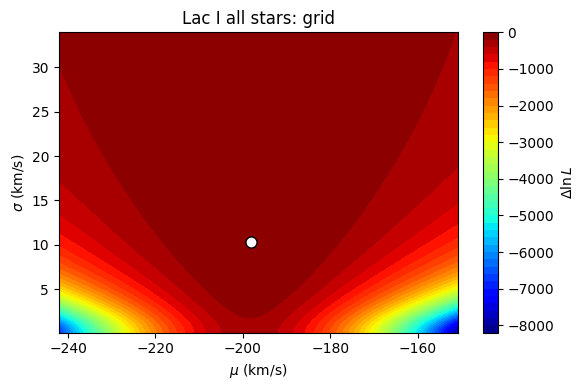

grid best mu = -198.09, sigma = 10.30, lnL = -484.99
acceptance rate = 0.624


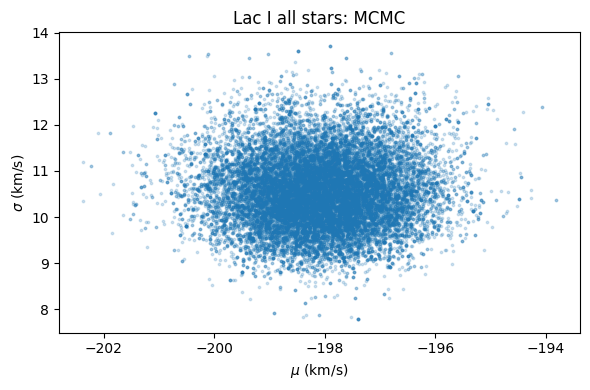

MCMC mu = -198.09 -1.03 +1.03
MCMC sigma = 10.51 -0.72 +0.82


In [18]:
lac1_all_chain, lac1_all_grid, lac1_all_mu_grid, lac1_all_sig_grid = calculate_2param(
    "data/lac1.csv",
    num=None,
    name="Lac I all stars",
    mu_step=1,
    sig_step=0.5,
)

===== Lac I first 10 stars =====
N = 10
data mean = -190.82, data std = 8.54


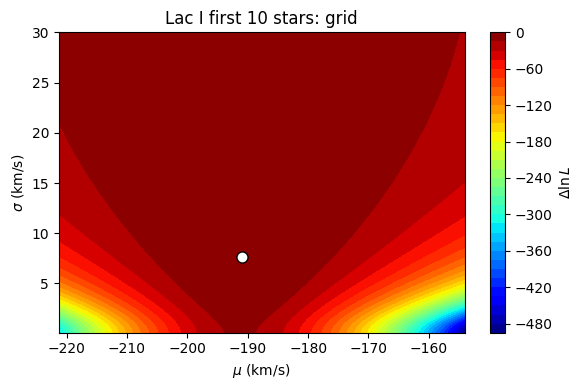

grid best mu = -190.89, sigma = 7.61, lnL = -35.73
acceptance rate = 0.866


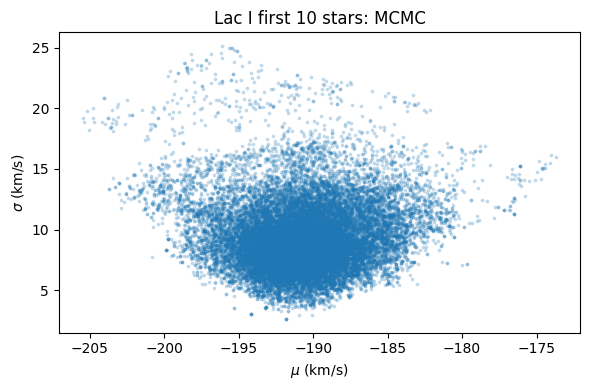

MCMC mu = -190.75 -3.19 +3.39
MCMC sigma = 9.06 -2.23 +3.04


In [19]:
lac1_10_chain, lac1_10_grid, lac1_10_mu_grid, lac1_10_sig_grid = calculate_2param(
    "data/lac1.csv",
    num=10,
    name="Lac I first 10 stars",
    mu_step=1,
    sig_step=0.5,
)

===== Cas III all stars =====
N = 212
data mean = -371.50, data std = 9.60


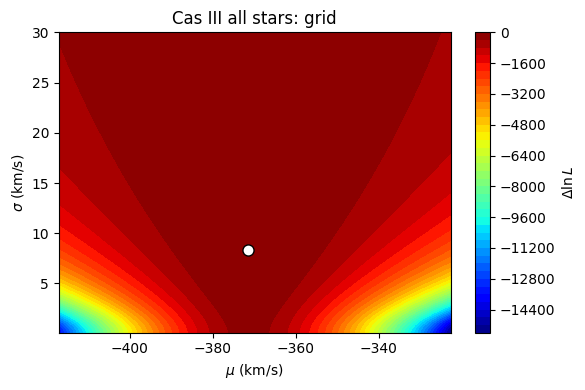

grid best mu = -371.53, sigma = 8.36, lnL = -778.02
acceptance rate = 0.580


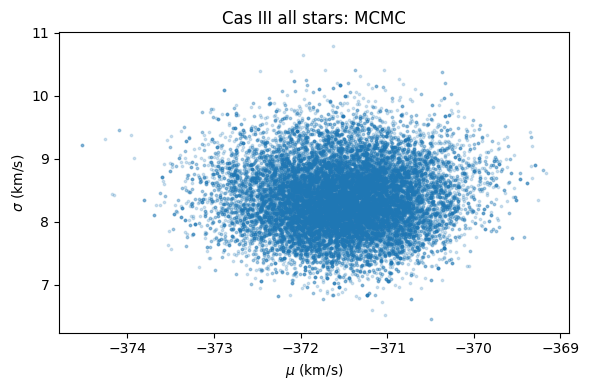

MCMC mu = -371.51 -0.65 +0.64
MCMC sigma = 8.34 -0.49 +0.56


In [20]:
cas3_all_chain, cas3_all_grid, cas3_all_mu_grid, cas3_all_sig_grid = calculate_2param(
    "data/cas3.csv",
    num=None,
    name="Cas III all stars",
    mu_step=0.7,
    sig_step=0.4,
)

===== Cas III first 10 stars =====
N = 10
data mean = -377.00, data std = 6.66


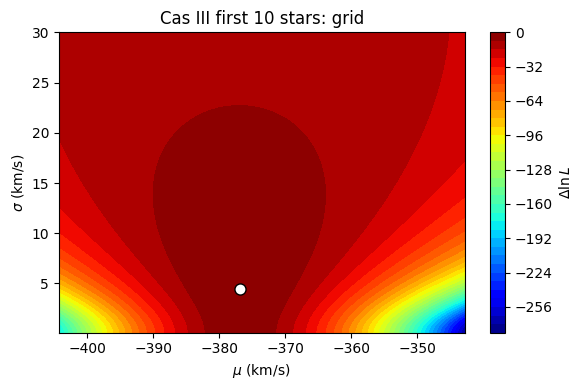

grid best mu = -376.83, sigma = 4.46, lnL = -33.04
acceptance rate = 0.876


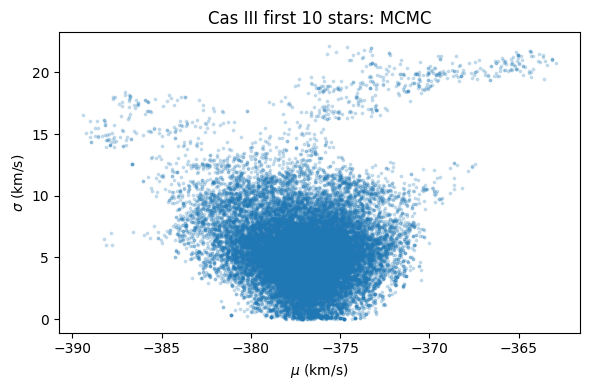

MCMC mu = -376.95 -2.53 +2.25
MCMC sigma = 5.40 -2.41 +3.11


In [21]:
cas3_10_chain, cas3_10_grid, cas3_10_mu_grid, cas3_10_sig_grid = calculate_2param(
    "data/cas3.csv",
    num=10,
    name="Cas III first 10 stars",
    mu_step=0.7,
    sig_step=0.4,
)

===== Per I all stars =====
N = 12
data mean = -325.98, data std = 8.57


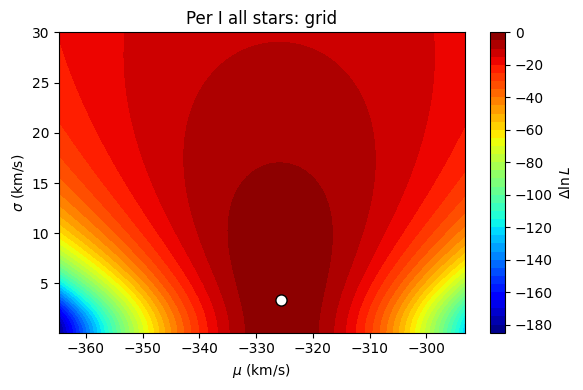

grid best mu = -325.61, sigma = 3.41, lnL = -42.28
acceptance rate = 0.848


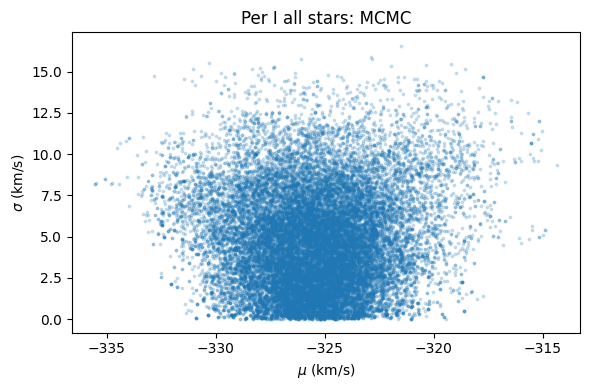

MCMC mu = -325.49 -2.58 +2.52
MCMC sigma = 4.53 -2.99 +3.46


In [22]:
per1_all_chain, per1_all_grid, per1_all_mu_grid, per1_all_sig_grid = calculate_2param(
    "data/per1.csv",
    num=None,
    name="Per I all stars",
    mu_step=1,
    sig_step=0.5,
)

===== Lac I total data =====
N = 169
initial parameters:
mu_dw = -198.06, sig_dw = 11.36
mu_mw = -77.90, sig_mw = 41.05
f = 0.746
acceptance rate = 0.542


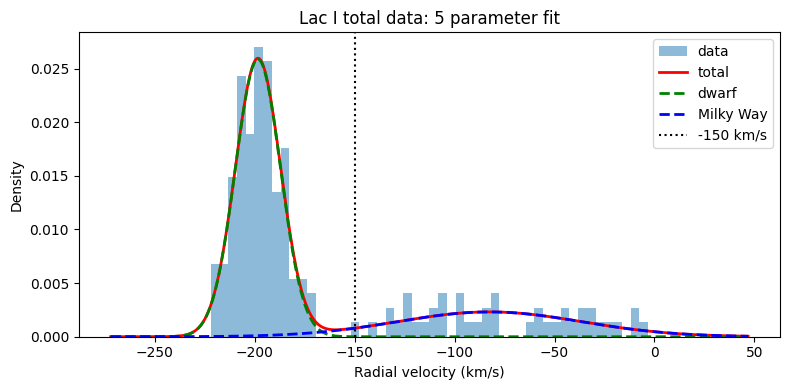

mu_dw = -198.39, sig_dw = 10.29
mu_mw = -82.57, sig_mw = 45.88
f = 0.733


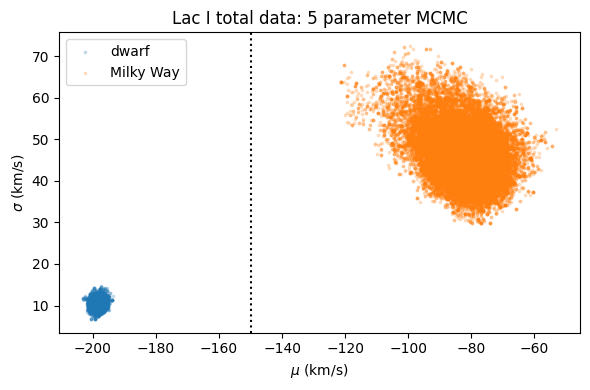

In [23]:
lac1_mix_chain = calculate_5param(
    "data/Lac1_total.csv",
    name="Lac I total data",
    mu_dw_step=1,
    sig_dw_step=0.5,
    mu_mw_step=2,
    sig_mw_step=2,
    f_step=0.02,
)

===== Cas III total data =====
N = 317
initial parameters:
mu_dw = -371.50, sig_dw = 9.62
mu_mw = -85.29, sig_mw = 40.40
f = 0.669
acceptance rate = 0.430


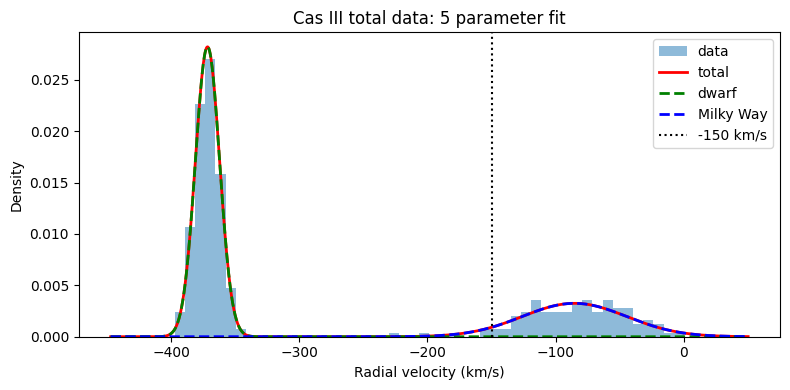

mu_dw = -371.53, sig_dw = 8.35
mu_mw = -85.30, sig_mw = 40.40
f = 0.669


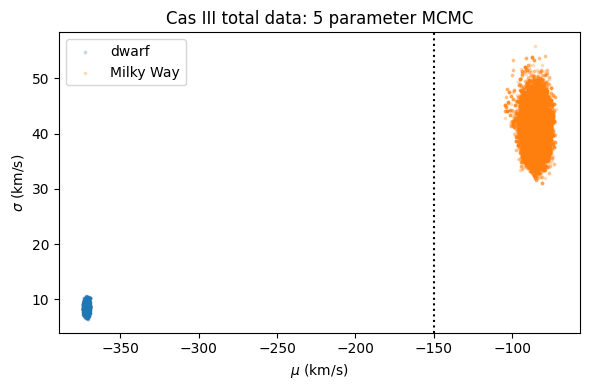

In [24]:
cas3_mix_chain = calculate_5param(
    "data/Cas3_total.csv",
    name="Cas III total data",
    mu_dw_step=0.7,
    sig_dw_step=0.4,
    mu_mw_step=2,
    sig_mw_step=2,
    f_step=0.02,
)

===== Per I total data =====
N = 40
initial parameters:
mu_dw = -325.98, sig_dw = 8.95
mu_mw = -63.09, sig_mw = 38.30
f = 0.300
acceptance rate = 0.739


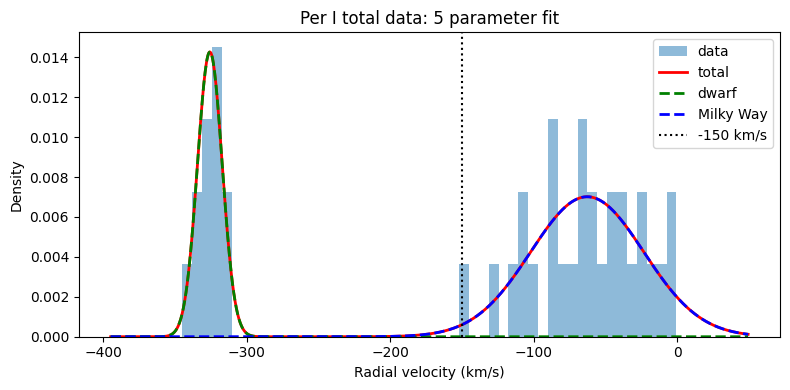

mu_dw = -325.59, sig_dw = 4.87
mu_mw = -62.60, sig_mw = 38.72
f = 0.308


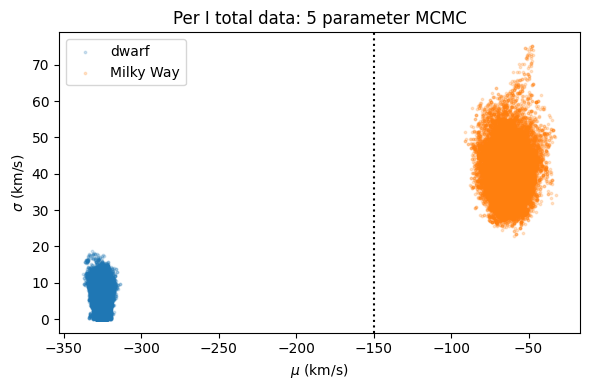

In [25]:
per1_mix_chain = calculate_5param(
    "data/Per1_total.csv",
    name="Per I total data",
    mu_dw_step=1,
    sig_dw_step=0.5,
    mu_mw_step=2,
    sig_mw_step=2,
    f_step=0.02,
)